In [5]:
import matplotlib.pyplot as plt
import sys, os

# Add the project root to the Python path to allow imports from the agents module
sys.path.append("..")
os.environ["ROOT_DIR"] = ".."  # this allows to use relative paths in config files


from result_inspection.experiment import Experiment
from result_inspection.toy_maze_geodesic import *

from agents.maze_agents.toy_maze.env.maze_env import Env
# Spiral 미로 환경 생성
maze_type = 'square_b'
env = Env(n=1, maze_type=maze_type, use_antigoal=False)
# 가짜 exp 객체 (visualize 함수들이 exp.learner.agent.env 구조를 기대하므로
class MockExperiment:
    def __init__(self, env):
        self.name = "spiral_debug"
        self.learner = type('obj', (object,), {
            'agent': type('obj', (object,), {'env': env}),
            'vae': None # VAE가 없어도 라플라시안 분석은 가능
        })
exp = MockExperiment(env)


Building Initial Maze Graph:  29%|██▉       | 441/1521 [00:00<00:00, 2233.70it/s]

Building graph for geodesic distance calculation (may take a moment)...


Building Initial Maze Graph: 100%|██████████| 1521/1521 [00:00<00:00, 2204.20it/s]


Graph Pruning: Kept 1521 nodes (Largest Component) out of 1521 initial valid nodes.
Geodesic distance: 10.61


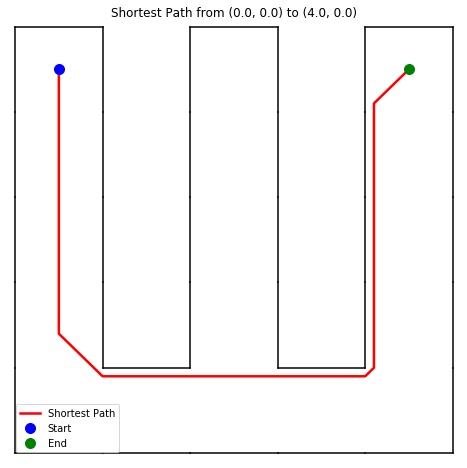

In [6]:
# 시작점과 끝점 정의
start_pos = (0.0, 0.0)
end_pos = (4.0, 0.0)
# 시각화 함수 호출
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
visualize_single_geodesic_path(exp, start_pos, end_pos, ax=ax, resolution=0.1)
plt.show()


Building Initial Maze Graph: 100%|██████████| 336/336 [00:00<00:00, 2356.87it/s]

Initializing Geodesic Calculator...



Calculating paired distances: 100%|██████████| 84/84 [00:00<00:00, 4173.34it/s]

Graph Pruning: Kept 336 nodes (Largest Component) out of 336 initial valid nodes.
Sampling 100 valid states from the environment...
Found 84 states corresponding to graph nodes.


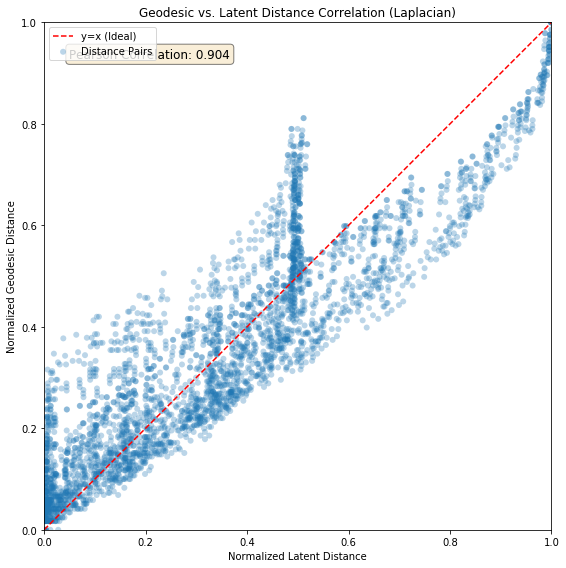

In [7]:

phi_encoder = load_laplacian_encoder(maze_type=maze_type, experiment_name="default")
visualize_geodesic_distance_correlation(
    exp,
    encoder=phi_encoder,
    num_samples=100,
    grid_resolution=0.2,
    title_suffix="(Laplacian)"
)

plt.tight_layout()
plt.show()

Building Initial Maze Graph: 100%|██████████| 1521/1521 [00:00<00:00, 2261.27it/s]


Graph Pruning: Kept 1521 nodes (Largest Component) out of 1521 initial valid nodes.


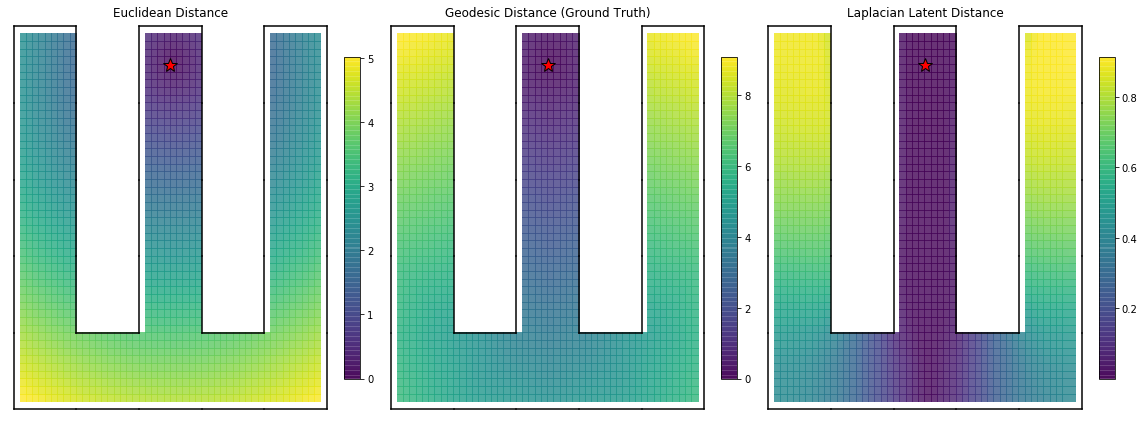

In [ ]:
import torch
import numpy as np
import sys, os

# Add the project root to the Python path to allow imports from the agents module
sys.path.append("..")
os.environ["ROOT_DIR"] = ".."  # this allows to use relative paths in config files

from result_inspection.experiment import Experiment
from result_inspection.toy_maze_geodesic import *


# 1. 모델 및 계산기 준비
phi_encoder = load_laplacian_encoder(maze_type=maze_type)
geo_calc = GeodesicDistanceCalculator(exp.learner.agent.env.maze,
maze_type=maze_type, resolution=0.1)
vae = exp.learner.vae
# 2. Metric 함수 정의
def metric_euclidean(S, s0):
    S_t = torch.tensor(S, dtype=torch.float32)
    s0_t = torch.tensor(s0, dtype=torch.float32).unsqueeze(0)
    return torch.norm(S_t - s0_t, dim=1).detach().numpy()
def metric_laplacian(S, s0, effective_dim=None):
    S_t = torch.tensor(S, dtype=torch.float32)
    s0_t = torch.tensor(s0, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        phi_S = phi_encoder(S_t)
        phi_s0 = phi_encoder(s0_t)
        if effective_dim is not None:
            phi_S = phi_S[:effective_dim]
            phi_s0 = phi_s0[:effective_dim]
    return torch.norm(phi_S - phi_s0, dim=1).detach().numpy()
def metric_geodesic(S, s0):
    # This might be slow if we call get_shortest_path for every point one one.
    # But for heatmap visualization, we can use the pre-computed Dijkstra matrix if we snap points to grid.
    # The helper function handles iteration or batching?
    # visualize_distance_heatmap passes (N, 2) array.
    dists = []
    # Optimization: Use Dijkstra one-to-all from s0 if possible, 
    # but our current API is one-to-one. Let's iterate for now (might be slow).
    # Or better: Use geo_calc internal matrix.
    # Let's use the slow iterative way first for correctness, or optimize needed.
    # To optimize: s0_node_idx = geo_calc.coord_to_node[...] -> row of dist_matrix
    s0_grid = geo_calc._get_grid_coords(s0)
    if s0_grid not in geo_calc.coord_to_node:
        return np.full(len(S), np.nan)
    s0_idx = geo_calc.coord_to_node[s0_grid]
    # Get all distances from s0 using the pre-computed matrix
    # But S points might not align perfectly with graph nodes.
    # We should snap S points to nearest nodes.
    for p in S:
        p_grid = geo_calc._get_grid_coords(p)
        if p_grid in geo_calc.coord_to_node:
            p_idx = geo_calc.coord_to_node[p_grid]
            d = geo_calc.dist_matrix[s0_idx, p_idx]
            dists.append(d)
        else:
            dists.append(np.nan)
    return np.array(dists)
# 3. 기준점 설정
s0 = (2.0, 0.0) # Example start point
# 4. 시각화 (3개 서브플롯)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes = axes.flatten()
metrics = [
    (metric_euclidean, "Euclidean Distance"),
    (metric_geodesic, "Geodesic Distance (Ground Truth)"),
    (metric_laplacian, "Laplacian Latent Distance")
]
for ax, (fn, title) in zip(axes, metrics):
    visualize_distance_heatmap(exp, fn, s0=s0, ax=ax, resolution=0.1,
title=title)
plt.tight_layout()
plt.show()
